# Explainability with SHAP

Uses SHAP to provide global feature importance and local explanations for model predictions.

## 1. Imports & Load Artifacts

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# ── Load model and metadata ───────────────────────────────────────────────────
best_estimator = joblib.load('../models/best_model.pkl')
metadata       = joblib.load('../models/model_metadata.pkl')

print(f"Model    : {metadata['model_name']}")
print(f"Features : {len(metadata['feature_names'])}")
print(f"Threshold: {metadata['threshold']}")

Model    : XGBoost
Features : 39
Threshold: 0.67


## 2. Reconstruct Features

In [2]:
df = pd.read_csv('../data/processed/processed_dataset.csv')

UNSCALED_TO_DROP = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'semester_performance_delta'
]
TARGET_COLS = ['Target', 'Target_Encoded', 'Target_Binary']

X = df.drop(columns=TARGET_COLS + UNSCALED_TO_DROP)

enrolled_mask = df['Target'] == 'Enrolled'
X_enrolled    = X[enrolled_mask].reset_index(drop=True)
df_enrolled   = df[enrolled_mask].reset_index(drop=True)

# Recompute dropout probabilities and risk tiers (mirrors Phase 4)
dropout_proba = best_estimator.predict_proba(X_enrolled)[:, 1]

risk_tiers = pd.cut(
    dropout_proba,
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=['Low', 'Moderate', 'High', 'Critical'],
)

df_enrolled['dropout_probability'] = dropout_proba
df_enrolled['Risk_Tier']           = risk_tiers

print(f'Enrolled students : {X_enrolled.shape[0]}')
print('Risk Tier counts  :')
print(df_enrolled['Risk_Tier'].value_counts().reindex(['Critical','High','Moderate','Low']))

Enrolled students : 794
Risk Tier counts  :
Risk_Tier
Critical    304
High        345
Moderate    145
Low           0
Name: count, dtype: int64


## 3. SHAP TreeExplainer

Extracts XGBoost from the pipeline and initializes the explainer.

In [3]:
# ── Extract the XGBoost classifier from the imblearn Pipeline ─────────────────
# The pipeline structure is: Pipeline([('smote', SMOTE(...)), ('clf', XGBClassifier(...))])
xgb_model = best_estimator.named_steps['clf']

# ── Build the clean feature matrix for SHAP ───────────────────────────────────
# Drop any non-feature columns that may have been added in Phase 4
COLS_TO_DROP_FOR_SHAP = ['dropout_probability', 'Risk_Tier'] + TARGET_COLS + UNSCALED_TO_DROP
existing_drop = [c for c in COLS_TO_DROP_FOR_SHAP if c in df_enrolled.columns]

X_shap = df_enrolled.drop(columns=existing_drop, errors='ignore')

# Align columns to exactly what the model was trained on
X_shap = X_shap[metadata['feature_names']]

print(f'SHAP input shape : {X_shap.shape}')
print(f'Features match   : {X_shap.columns.tolist() == metadata["feature_names"]}')

# ── Initialize TreeExplainer ──────────────────────────────────────────────────
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for all enrolled students
# shap_values shape: (n_students, n_features)
shap_values = explainer(X_shap)

print(f'SHAP values shape: {shap_values.values.shape}')
print('TreeExplainer initialized successfully.')

SHAP input shape : (794, 39)
Features match   : True
SHAP values shape: (794, 39)
TreeExplainer initialized successfully.


## 4. Global Feature Importance

Bar chart showing mean absolute SHAP values.

Top 10 features by mean |SHAP| value:
                                feature  mean_abs_shap
    Curricular units 2nd sem (approved)       0.701809
                Tuition fees up to date       0.141946
    Curricular units 1st sem (approved)       0.127031
                     Scholarship holder       0.089305
               Age at enrollment_scaled       0.075435
                                 Course       0.073757
                       Application mode       0.056992
Curricular units 2nd sem (grade)_scaled       0.046348
      semester_performance_delta_scaled       0.038594
                    Father's occupation       0.036980

Plot saved to: ../models/shap_global_importance.png


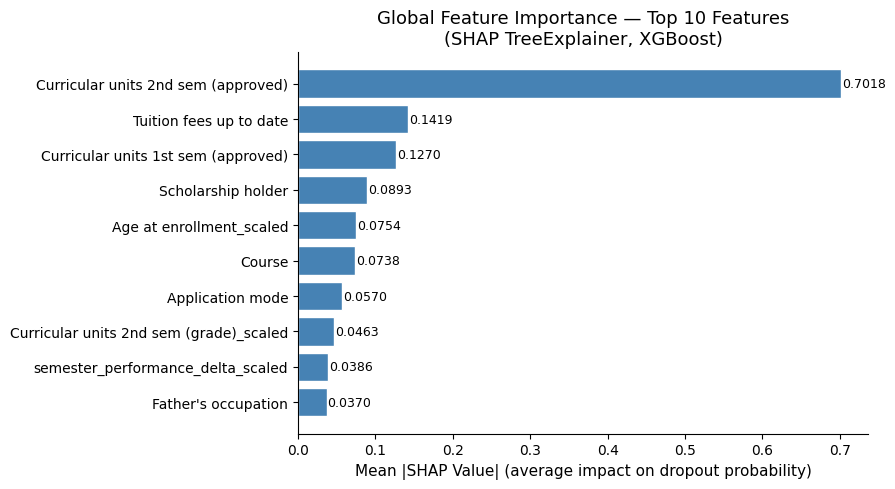

In [4]:
# ── Compute mean |SHAP| per feature and select top 10 ────────────────────────
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_names = X_shap.columns.tolist()

importance_df = (
    pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Top 10 features by mean |SHAP| value:')
print(importance_df.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['mean_abs_shap'][::-1],
    color='steelblue',
    edgecolor='white',
)

ax.set_xlabel('Mean |SHAP Value| (average impact on dropout probability)', fontsize=11)
ax.set_title('Global Feature Importance — Top 10 Features\n(SHAP TreeExplainer, XGBoost)', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)

# Annotate bars with values
for bar, val in zip(bars, importance_df['mean_abs_shap'][::-1]):
    ax.text(
        bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', ha='left', fontsize=9
    )

plt.tight_layout()

# ── Save for Streamlit dashboard ──────────────────────────────────────────────
save_path = '../models/shap_global_importance.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nPlot saved to: {save_path}')

plt.show()

## 5. Local Waterfall Plot

Explains prediction for a specific student.
- Red: increases risk
- Blue: decreases risk

Selected student index : 14
Dropout probability    : 0.9308
Risk tier              : Critical


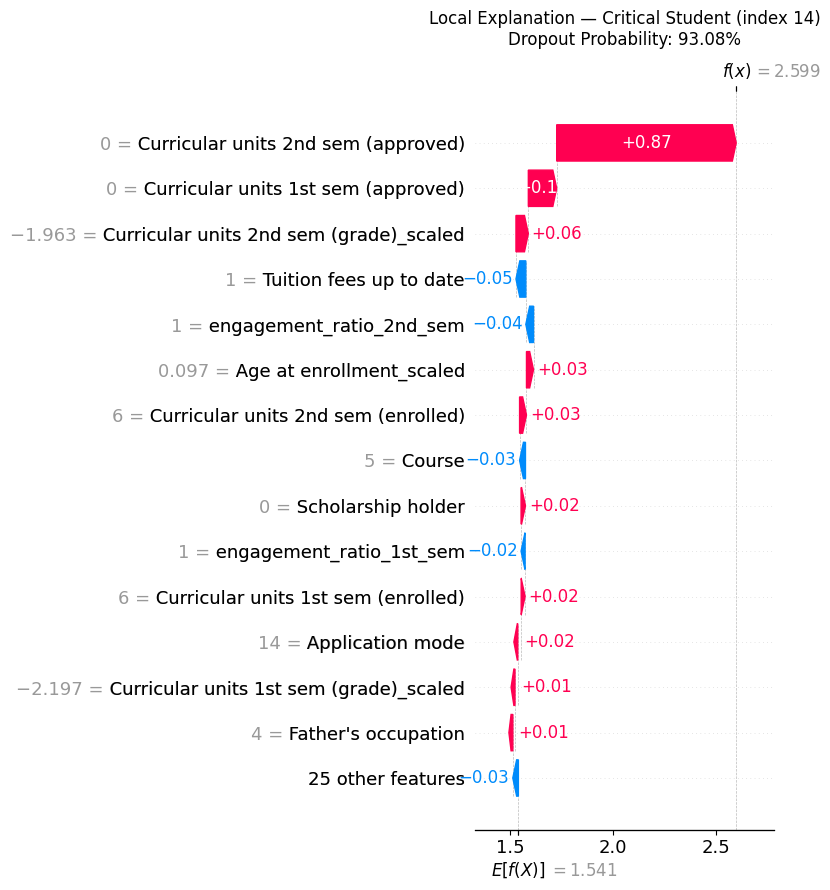

In [5]:
# ── Select the highest-risk Critical student ──────────────────────────────────
critical_mask = df_enrolled['Risk_Tier'] == 'Critical'

if critical_mask.sum() == 0:
    raise ValueError('No Critical-tier students found. Check risk tier assignment in Phase 4.')

# Pick the student with the highest dropout probability among Critical tier
critical_idx = df_enrolled.loc[critical_mask, 'dropout_probability'].idxmax()

student_proba = df_enrolled.loc[critical_idx, 'dropout_probability']
print(f'Selected student index : {critical_idx}')
print(f'Dropout probability    : {student_proba:.4f}')
print(f'Risk tier              : {df_enrolled.loc[critical_idx, "Risk_Tier"]}')

# ── Waterfall plot ────────────────────────────────────────────────────────────
# shap_values[critical_idx] is an Explanation object for this single student
fig, ax = plt.subplots(figsize=(10, 6))

shap.plots.waterfall(
    shap_values[critical_idx],
    max_display=15,   # show top 15 contributors; rest collapsed into "other features"
    show=False,
)

plt.title(
    f'Local Explanation — Critical Student (index {critical_idx})\n'
    f'Dropout Probability: {student_proba:.2%}',
    fontsize=12,
    pad=12,
)
plt.tight_layout()
plt.show()